<a href="https://colab.research.google.com/github/Syamchand123/Typhoon-prediction/blob/main/mini_project(16_8_25)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# Phase 1 (Robust Method): Load Data from Google Drive and Process
# ==============================================================================
import pandas as pd
import numpy as np
from google.colab import drive

# --- 1. MOUNT GOOGLE DRIVE ---
# This will prompt you for authorization. Follow the link, get the code, and paste it.
print("Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

# --- 2. DEFINE THE FILE PATH ---
# IMPORTANT: This path assumes you created a 'Colab_Data' folder in your main drive.
# If you used a different folder, you MUST update the path below.
file_path = "/content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs.ALL.list.v04r00.csv"
print(f"Attempting to load data from: {file_path}")

# --- 3. LOAD THE DATA ---
# Load the CSV file into a pandas DataFrame.
try:
    # This dataset has mixed data types, so we use low_memory=False to avoid warnings.
    df_raw = pd.read_csv(file_path, low_memory=False, skiprows=[1], na_values=[' ', 'NOT_A_NUMBER'])
    print("File loaded successfully from Google Drive.")

    # --- 4. INITIAL CLEANING AND TYPE CONVERSION ---
    print("Converting 'ISO_TIME' to datetime objects...")
    df_raw['ISO_TIME'] = pd.to_datetime(df_raw['ISO_TIME'])

    # Select a subset of columns relevant to our input/output list.
    columns_to_keep = [
        'SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
        'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES'
    ]
    df = df_raw[columns_to_keep].copy()

    # --- 5. FILTER THE DATA FOR NORTHWEST PACIFIC (WP) ---
    print("Filtering data for Northwest Pacific (WP) basin, season >= 1980...")
    df_filtered = df[(df['BASIN'] == 'WP') & (df['SEASON'] >= 1980)].copy()

    # Filter for only Tropical Cyclones ('TS' - Tropical Storm nature)
    df_filtered = df_filtered[df_filtered['NATURE'] == 'TS'].copy()

    # --- 6. HANDLE MISSING VALUES ---
    print("\nMissing values before cleaning:")
    print(df_filtered[['WMO_WIND', 'WMO_PRES']].isnull().sum())

    # Interpolate missing wind/pressure values within each unique storm track.
    df_filtered['WMO_WIND'] = df_filtered.groupby('SID')['WMO_WIND'].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    df_filtered['WMO_PRES'] = df_filtered.groupby('SID')['WMO_PRES'].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    df_filtered.dropna(subset=['WMO_WIND', 'WMO_PRES'], inplace=True)

    print("\nMissing values after cleaning:")
    print(df_filtered[['WMO_WIND', 'WMO_PRES']].isnull().sum())

    # --- 7. DISPLAY THE RESULT ---
    print(f"\nPHASE 1 COMPLETE. Shape of the final DataFrame: {df_filtered.shape}")
    print("Here are the first 5 rows of our clean, filtered dataset:")
    display(df_filtered.head())

except FileNotFoundError:
    print("\nERROR: FileNotFoundError!")
    print("The file was not found at the specified path. Please check the following:")
    print("1. Did you upload the 'ibtracs.ALL.list.v04r00.csv' file to your Google Drive?")
    print("2. Is it in a folder named 'Colab_Data' inside 'My Drive'?")
    print("3. If you used a different folder, did you update the 'file_path' variable in the code?")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.
Attempting to load data from: /content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs.ALL.list.v04r00.csv
File loaded successfully from Google Drive.
Converting 'ISO_TIME' to datetime objects...
Filtering data for Northwest Pacific (WP) basin, season >= 1980...

Missing values before cleaning:
WMO_WIND    47882
WMO_PRES    38006
dtype: int64

Missing values after cleaning:
WMO_WIND    0
WMO_PRES    0
dtype: int64

PHASE 1 COMPLETE. Shape of the final DataFrame: (66227, 12)
Here are the first 5 rows of our clean, filtered dataset:


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
426220,1980094N02179,1980,33,WP,MM,CARMEN,1980-04-05 00:00:00,TS,9.26316,179.589,40.0,1002.0
426221,1980094N02179,1980,33,WP,MM,CARMEN,1980-04-05 03:00:00,TS,9.72132,179.075,40.0,1001.0
426222,1980094N02179,1980,33,WP,MM,CARMEN,1980-04-05 06:00:00,TS,10.24930,178.559,40.0,1000.0
426223,1980094N02179,1980,33,WP,MM,CARMEN,1980-04-05 09:00:00,TS,10.91220,178.124,40.0,997.0
426224,1980094N02179,1980,33,WP,MM,CARMEN,1980-04-05 12:00:00,TS,11.65000,177.783,40.0,994.0


In [ ]:

#DONT RUN
#small one (100 rows)


# ==============================================================================
# Phase 2 (Corrected): Download and Integrate Environmental Data from ERA5
# ==============================================================================
# --- 0. INSTALL THE REQUIRED LIBRARY ---
# We need to install the 'cdsapi' library to access the Copernicus Climate Data Store.






!pip install -q cdsapi

# --- Now, we can import the libraries ---
import pandas as pd
import numpy as np
import cdsapi
import xarray as xr
import getpass
from tqdm.auto import tqdm

# --- 1. SETUP THE CDS API KEY (Corrected Method) ---
# This cell will securely prompt you for your API Key only.
# It then writes it to the required .cdsapirc file in the correct format.

api_key = getpass.getpass("Enter your CDS API Key:")

# Write the credentials to the .cdsapirc file in the new, correct format
with open("/root/.cdsapirc", "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n") # Correct URL
    f.write(f"key: {api_key}\n")                          # Correct key format (no UID)

print("CDS API credentials configured successfully.")

# --- 2. PREPARE A SAMPLE OF THE DATA FOR TESTING ---
# (This part remains the same)
print(f"Original DataFrame has {len(df_filtered)} points.")
df_sample = df_filtered.sample(n=100, random_state=42).copy()
df_sample = df_sample.sort_values(by='ISO_TIME').reset_index(drop=True)
print(f"Created a sample of {len(df_sample)} points for this demonstration.")

# --- 3. BATCH DOWNLOAD AND PROCESS ERA5 DATA ---
# (This part remains the same)

# Initialize the CDS client
c = cdsapi.Client()
environmental_data = []

print("\nStarting to download environmental data in batches (by month)...")
# Group by year and month
# Using tqdm to show a progress bar for the loop
for group_name, group_df in tqdm(df_sample.groupby([df_sample['ISO_TIME'].dt.year, df_sample['ISO_TIME'].dt.month]), desc="Monthly Batches"):
    year, month = group_name

    # Define the geographic bounding box for this month's data points
    north = group_df['LAT'].max() + 1
    south = group_df['LAT'].min() - 1
    west = group_df['LON'].min() - 1
    east = group_df['LON'].max() + 1

    try:
        # Define the API request for surface-level variables
        c.retrieve(
            'reanalysis-era5-single-levels',
            {
                'product_type': 'reanalysis',
                'format': 'netcdf',
                'variable': ['sea_surface_temperature', '2m_temperature'],
                'year': str(year),
                'month': f'{month:02d}',
                'day': [f'{d:02d}' for d in sorted(list(set(group_df.ISO_TIME.dt.day)))],
                'time': ['00:00', '06:00', '12:00', '18:00'],
                'area': [north, west, south, east],
            },
            'era5_surface.nc'
        )

        # Define the API request for pressure-level variables
        c.retrieve(
            'reanalysis-era5-pressure-levels',
            {
                'product_type': 'reanalysis',
                'format': 'netcdf',
                'variable': ['relative_humidity', 'u_component_of_wind', 'v_component_of_wind'],
                'pressure_level': ['200', '500', '850'],
                'year': str(year),
                'month': f'{month:02d}',
                'day': [f'{d:02d}' for d in sorted(list(set(group_df.ISO_TIME.dt.day)))],
                'time': ['00:00', '06:00', '12:00', '18:00'],
                'area': [north, west, south, east],
            },
            'era5_pressure.nc'
        )

        # Load the downloaded data using xarray
        ds_surface = xr.open_dataset('era5_surface.nc')
        ds_pressure = xr.open_dataset('era5_pressure.nc')
        ds = xr.merge([ds_surface, ds_pressure])

        if 'valid_time' in ds.dims:
            ds = ds.rename({'valid_time': 'time'})

        if 'pressure_level' in ds.dims:
            ds = ds.rename({'pressure_level': 'level'})

        # For each point in this month's group, extract the data
        for index, row in group_df.iterrows():
            data_point = ds.sel(
                time=row['ISO_TIME'],
                latitude=row['LAT'],
                longitude=row['LON'],
                method='nearest'
            )

            environmental_data.append({
                'SID': row['SID'],
                'ISO_TIME': row['ISO_TIME'],
                'SST': data_point['sst'].values.item() - 273.15, # Convert Kelvin to Celsius
                'RH_500': data_point['r'].sel(level=500).values.item(),
                'RH_850': data_point['r'].sel(level=850).values.item(),
                'U_200': data_point['u'].sel(level=200).values.item(),
                'V_200': data_point['v'].sel(level=200).values.item(),
                'U_850': data_point['u'].sel(level=850).values.item(),
                'V_850': data_point['v'].sel(level=850).values.item(),
            })

    except Exception as e:
        print(f"Could not process data for {year}-{month}. Error: {e}")

# --- 4. MERGE THE DATASETS ---
df_env = pd.DataFrame(environmental_data)

# Merge the environmental data back into our sample DataFrame
df_sample_enriched = pd.merge(df_sample, df_env, on=['SID', 'ISO_TIME'], how='left')

print("\nPHASE 2 COMPLETE for the sample.")
print(f"Successfully enriched {len(df_sample_enriched[df_sample_enriched['SST'].notna()])} data points.")
print("Here are the first 5 rows of the new enriched DataFrame:")
display(df_sample_enriched.head())

Enter your CDS API Key:··········


2025-08-17 06:53:59,707 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


CDS API credentials configured successfully.
Original DataFrame has 66227 points.
Created a sample of 100 points for this demonstration.

Starting to download environmental data in batches (by month)...


Monthly Batches:   0%|          | 0/84 [00:00<?, ?it/s]

2025-08-17 06:54:00,327 INFO Request ID is 1ff10ec9-ed39-4a83-a798-b8a799ec4c10
INFO:ecmwf.datastores.legacy_client:Request ID is 1ff10ec9-ed39-4a83-a798-b8a799ec4c10
2025-08-17 06:54:00,395 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 06:54:05,407 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-17 06:54:08,838 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


...

736a4b67bb866b2c59a1ce3cea6e17e1.nc:   0%|          | 0.00/584k [00:00<?, ?B/s]

2025-08-17 06:55:27,147 INFO Request ID is 87577f01-25ad-4d70-8640-ee8cd1fd3482
INFO:ecmwf.datastores.legacy_client:Request ID is 87577f01-25ad-4d70-8640-ee8cd1fd3482
2025-08-17 06:55:27,189 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 06:55:35,629 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


d1299bf854e5bd685df86e9bcfa1c64f.nc:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

2025-08-17 06:55:36,119 INFO Request ID is 97853fa7-575b-4d3b-890d-c49658cd5350
INFO:ecmwf.datastores.legacy_client:Request ID is 97853fa7-575b-4d3b-890d-c49658cd5350
2025-08-17 06:55:36,163 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 06:55:41,039 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# CORRECTED Phase 2: Resampling Entire Storms and Fetching Environmental Data
# ==============================================================================

#big one (900 rows)



import pandas as pd
import numpy as np
import cdsapi
import xarray as xr
import getpass
from tqdm.auto import tqdm

# --- 1. CORRECT SAMPLING STRATEGY ---
# Instead of sampling random points, we will sample random entire storms.

# Get a list of all unique storm IDs from our clean Phase 1 data
all_sids = df_filtered['SID'].unique()

# Set a random seed for reproducibility and select 15 random storms
np.random.seed(42)
sample_sids = np.random.choice(all_sids, size=15, replace=False)

# Create the new sample DataFrame by taking ALL rows belonging to our selected storms
df_sample = df_filtered[df_filtered['SID'].isin(sample_sids)].copy()
df_sample = df_sample.sort_values(by=['SID', 'ISO_TIME']).reset_index(drop=True)

print("Corrected Sampling Strategy:")
print(f"Selected {len(sample_sids)} unique storms for the new sample.")
print(f"The new sample DataFrame has {len(df_sample)} data points (rows).")


# --- 2. SETUP THE CDS API KEY ---
# (This part is the same as before)
api_key = getpass.getpass("Enter your CDS API Key:")
with open("/root/.cdsapirc", "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {api_key}\n")
print("CDS API credentials configured successfully.")

# --- 3. BATCH DOWNLOAD AND PROCESS ERA5 DATA (for the new, good sample) ---
c = cdsapi.Client()
environmental_data = []

print("\nStarting to download environmental data for the new sample...")
for group_name, group_df in tqdm(df_sample.groupby([df_sample['ISO_TIME'].dt.year, df_sample['ISO_TIME'].dt.month]), desc="Monthly Batches"):
    year, month = group_name

    north = group_df['LAT'].max() + 1
    south = group_df['LAT'].min() - 1
    west = group_df['LON'].min() - 1
    east = group_df['LON'].max() + 1

    try:
        c.retrieve(
            'reanalysis-era5-single-levels',
            {'product_type': 'reanalysis', 'format': 'netcdf', 'variable': ['sea_surface_temperature', '2m_temperature'], 'year': str(year), 'month': f'{month:02d}', 'day': [f'{d:02d}' for d in sorted(list(set(group_df.ISO_TIME.dt.day)))], 'time': ['00:00', '06:00', '12:00', '18:00'], 'area': [north, west, south, east]},
            'era5_surface.nc'
        )
        c.retrieve(
            'reanalysis-era5-pressure-levels',
            {'product_type': 'reanalysis', 'format': 'netcdf', 'variable': ['relative_humidity', 'u_component_of_wind', 'v_component_of_wind'], 'pressure_level': ['200', '500', '850'], 'year': str(year), 'month': f'{month:02d}', 'day': [f'{d:02d}' for d in sorted(list(set(group_df.ISO_TIME.dt.day)))], 'time': ['00:00', '06:00', '12:00', '18:00'], 'area': [north, west, south, east]},
            'era5_pressure.nc'
        )

        ds_surface = xr.open_dataset('era5_surface.nc')
        ds_pressure = xr.open_dataset('era5_pressure.nc')
        ds = xr.merge([ds_surface, ds_pressure])

        if 'valid_time' in ds.dims: ds = ds.rename({'valid_time': 'time'})
        if 'pressure_level' in ds.dims: ds = ds.rename({'pressure_level': 'level'})

        for index, row in group_df.iterrows():
            data_point = ds.sel(time=row['ISO_TIME'], latitude=row['LAT'], longitude=row['LON'], method='nearest')
            environmental_data.append({
                'SID': row['SID'], 'ISO_TIME': row['ISO_TIME'],
                'SST': data_point['sst'].values.item() - 273.15,
                'RH_500': data_point['r'].sel(level=500).values.item(),
                'RH_850': data_point['r'].sel(level=850).values.item(),
                'U_200': data_point['u'].sel(level=200).values.item(),
                'V_200': data_point['v'].sel(level=200).values.item(),
                'U_850': data_point['u'].sel(level=850).values.item(),
                'V_850': data_point['v'].sel(level=850).values.item(),
            })
    except Exception as e:
        print(f"Could not process data for {year}-{month}. Error: {e}")

# --- 4. MERGE THE DATASETS AND SAVE CHECKPOINT ---
df_env = pd.DataFrame(environmental_data)
df_sample_enriched = pd.merge(df_sample, df_env, on=['SID', 'ISO_TIME'], how='left')
df_sample_enriched.dropna(inplace=True) # Drop rows where env data failed

print("\nNEW ENRICHED SAMPLE CREATED.")
print(f"Successfully enriched {len(df_sample_enriched)} data points from {df_sample_enriched['SID'].nunique()} storms.")

# Save this good sample to drive
save_path = "/content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_storm_sample_with_env_data.csv"
df_sample_enriched.to_csv(save_path, index=False)
print(f"\nSaved the new, correct sample to: {save_path}")

Corrected Sampling Strategy:
Selected 15 unique storms for the new sample.
The new sample DataFrame has 993 data points (rows).
Enter your CDS API Key:··········


2025-08-17 06:56:11,168 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


CDS API credentials configured successfully.

Starting to download environmental data for the new sample...


Monthly Batches:   0%|          | 0/17 [00:00<?, ?it/s]

2025-08-17 06:56:11,532 INFO Request ID is 91a5a2d4-4b78-4138-93b0-bd1bfaa41140
INFO:ecmwf.datastores.legacy_client:Request ID is 91a5a2d4-4b78-4138-93b0-bd1bfaa41140
2025-08-17 06:56:11,590 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 06:56:19,960 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# Phase 2 (Full Dataset): The Long Download - Final Verified Script
# ==============================================================================

## full(62000 rows)

!pip install -q cdsapi
import pandas as pd
import numpy as np
import cdsapi
import xarray as xr
from tqdm.auto import tqdm

# --- 1. USE THE FULL FILTERED DATAFRAME ---
df_full = df_filtered.copy()
print(f"Starting the full data download for {len(df_full)} data points.")
print("!!! THIS WILL TAKE 5-8 HOURS TO COMPLETE !!!")

# --- 2. INITIALIZE CDS CLIENT ---
c = cdsapi.Client()
environmental_data_full = []

# --- 3. BATCH DOWNLOAD AND PROCESS ERA5 DATA ---
print("\nStarting to download environmental data in batches (by month)...")
for group_name, group_df in tqdm(df_full.groupby([df_full['ISO_TIME'].dt.year, df_full['ISO_TIME'].dt.month]), desc="Monthly Batches"):
    year, month = group_name

    north = group_df['LAT'].max() + 1
    south = group_df['LAT'].min() - 1
    west = group_df['LON'].min() - 1
    east = group_df['LON'].max() + 1

    try:
        c.retrieve(
            'reanalysis-era5-single-levels',
            {'product_type': 'reanalysis', 'format': 'netcdf', 'variable': ['sea_surface_temperature', '2m_temperature'], 'year': str(year), 'month': f'{month:02d}', 'day': [f'{d:02d}' for d in sorted(list(set(group_df.ISO_TIME.dt.day)))], 'time': ['00:00', '06:00', '12:00', '18:00'], 'area': [north, west, south, east]},
            'era5_surface.nc'
        )
        c.retrieve(
            'reanalysis-era5-pressure-levels',
            {'product_type': 'reanalysis', 'format': 'netcdf', 'variable': ['relative_humidity', 'u_component_of_wind', 'v_component_of_wind'], 'pressure_level': ['200', '500', '850'], 'year': str(year), 'month': f'{month:02d}', 'day': [f'{d:02d}' for d in sorted(list(set(group_df.ISO_TIME.dt.day)))], 'time': ['00:00', '06:00', '12:00', '18:00'], 'area': [north, west, south, east]},
            'era5_pressure.nc'
        )

        ds_surface = xr.open_dataset('era5_surface.nc')
        ds_pressure = xr.open_dataset('era5_pressure.nc')
        ds = xr.merge([ds_surface, ds_pressure])

        # === CRITICAL FIXES ARE INCLUDED HERE ===
        if 'valid_time' in ds.dims: ds = ds.rename({'valid_time': 'time'})
        if 'pressure_level' in ds.dims: ds = ds.rename({'pressure_level': 'level'})
        # ========================================

        for index, row in group_df.iterrows():
            data_point = ds.sel(time=row['ISO_TIME'], latitude=row['LAT'], longitude=row['LON'], method='nearest')
            environmental_data_full.append({
                'SID': row['SID'], 'ISO_TIME': row['ISO_TIME'],
                'SST': data_point['sst'].values.item() - 273.15,
                'RH_500': data_point['r'].sel(level=500).values.item(),
                'RH_850': data_point['r'].sel(level=850).values.item(),
                'U_200': data_point['u'].sel(level=200).values.item(),
                'V_200': data_point['v'].sel(level=200).values.item(),
                'U_850': data_point['u'].sel(level=850).values.item(),
                'V_850': data_point['v'].sel(level=850).values.item(),
            })
    except Exception as e:
        print(f"Could not process data for {year}-{month}. Error: {e}")

# --- 4. MERGE THE DATASETS AND SAVE THE CHECKPOINT ---
df_env_full = pd.DataFrame(environmental_data_full)
df_full_enriched = pd.merge(df_full, df_env_full, on=['SID', 'ISO_TIME'], how='left')
df_full_enriched.dropna(inplace=True)

print("\n--- FULL DATA DOWNLOAD COMPLETE ---")
print(f"Successfully enriched {len(df_full_enriched)} data points.")

save_path_full = "/content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_full_with_env_data.csv"
df_full_enriched.to_csv(save_path_full, index=False)
print(f"\nSaved the full enriched dataset to: {save_path_full}")

2025-08-17 06:56:31,153 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


Starting the full data download for 66227 data points.
!!! THIS WILL TAKE 5-8 HOURS TO COMPLETE !!!

Starting to download environmental data in batches (by month)...


Monthly Batches:   0%|          | 0/376 [00:00<?, ?it/s]

2025-08-17 06:56:31,653 INFO Request ID is 7d030759-ade8-45fc-899e-b05fbefe46f1
INFO:ecmwf.datastores.legacy_client:Request ID is 7d030759-ade8-45fc-899e-b05fbefe46f1
2025-08-17 06:56:31,740 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 06:56:40,180 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


b33cc04365e21a29bc9f4af9a1eabc8e.nc:   0%|          | 0.00/63.4k [00:00<?, ?B/s]

...

5c73444b442675323942ad6d96ddef62.nc:   0%|          | 0.00/7.27M [00:00<?, ?B/s]

2025-08-17 16:41:41,303 INFO Request ID is 76e1564a-6a4b-43d7-9792-af2f52e726df
INFO:ecmwf.datastores.legacy_client:Request ID is 76e1564a-6a4b-43d7-9792-af2f52e726df
2025-08-17 16:41:41,575 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 16:41:50,033 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-17 16:42:14,347 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


4a86aa1066f387f4d075e0f7814987ea.nc:   0%|          | 0.00/7.70M [00:00<?, ?B/s]

2025-08-17 16:42:15,798 INFO Request ID is cd851d05-7b27-43c9-9f01-ee98277daed2
INFO:ecmwf.datastores.legacy_client:Request ID is cd851d05-7b27-43c9-9f01-ee98277daed2
2025-08-17 16:42:15,880 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-17 16:42:36,986 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# EMERGENCY SAVE SCRIPT: Save Partial Progress
# ==============================================================================
import pandas as pd

print("Attempting to save partial progress...")

# Check if the data list exists and has data in it
if 'environmental_data_full' in locals() and len(environmental_data_full) > 0:
    print(f"Found {len(environmental_data_full)} rows of downloaded data. Preparing to save...")

    # Convert the list of dictionaries to a DataFrame
    df_env_partial = pd.DataFrame(environmental_data_full)

    # Merge it with the original storm data to have a complete file
    # This ensures we know which storms these data points belong to
    df_partial_enriched = pd.merge(df_full, df_env_partial, on=['SID', 'ISO_TIME'], how='inner')

    # Define the save path for the partial file
    save_path_partial = "/content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_PARTIAL_download.csv"

    # Save the file
    df_partial_enriched.to_csv(save_path_partial, index=False)

    print("\n--- SUCCESS! ---")
    print(f"Successfully saved your {len(df_partial_enriched)} completed rows.")
    print(f"Your progress is now safe in Google Drive at: {save_path_partial}")

else:
    print("\nERROR: Could not find any data in the 'environmental_data_full' list.")
    print("This might happen if the cell was interrupted before it could collect any data.")

Attempting to save partial progress...
Found 47025 rows of downloaded data. Preparing to save...

--- SUCCESS! ---
Successfully saved your 47025 completed rows.
Your progress is now safe in Google Drive at: /content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_PARTIAL_download.csv


In [ ]:
# ==============================================================================
# Save the Enriched DataFrame to Google Drive as a Checkpoint
# ==============================================================================

try:
    # Define the path and filename for our checkpoint file.
    # It will be saved in the same 'Colab_Data' folder we used before.
    save_path = "/content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_sample_with_env_data.csv"

    print(f"Saving the enriched DataFrame to Google Drive...")
    print(f"Path: {save_path}")

    # Use the .to_csv() method to save the DataFrame.
    # index=False is important to prevent pandas from writing a new index column to the file.
    df_sample_enriched.to_csv(save_path, index=False)

    print("\nFile saved successfully!")
    print("You can now find 'ibtracs_wp_sample_with_env_data.csv' in your 'Colab_Data' folder on Google Drive.")

except NameError:
    print("ERROR: The DataFrame 'df_sample_enriched' was not found.")
    print("Please make sure you have successfully completed Phase 2 before running this cell.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Saving the enriched DataFrame to Google Drive...
Path: /content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_sample_with_env_data.csv

File saved successfully!
You can now find 'ibtracs_wp_sample_with_env_data.csv' in your 'Colab_Data' folder on Google Drive.


In [ ]:
# ==============================================================================
# Phase 3 (Using the Large Partial Dataset)
# ==============================================================================
import pandas as pd
import numpy as np

# --- 1. LOAD THE LARGE PARTIAL DATASET FROM GOOGLE DRIVE ---
print("Loading the large PARTIAL enriched dataset from Google Drive...")
# === CHANGE #1: Use the name of the file you just saved ===
partial_enriched_path = "/content/drive/MyDrive/Cyclone-TrackAI_Project/ibtracs_wp_PARTIAL_download.csv"
df_large_enriched = pd.read_csv(partial_enriched_path)
df_large_enriched['ISO_TIME'] = pd.to_datetime(df_large_enriched['ISO_TIME'])
print(f"Dataset with {len(df_large_enriched)} rows loaded successfully.")

# --- 2. RUN FEATURE ENGINEERING ---
# (The rest of this logic is identical to before)
print("Starting Feature Engineering...")
df_large_enriched['VWS'] = np.sqrt((df_large_enriched['U_200'] - df_large_enriched['U_850'])**2 + (df_large_enriched['V_200'] - df_large_enriched['V_850'])**2)
df_large_enriched = df_large_enriched.sort_values(by=['SID', 'ISO_TIME'])
df_large_enriched['dLAT'] = df_large_enriched.groupby('SID')['LAT'].diff()
df_large_enriched['dLON'] = df_large_enriched.groupby('SID')['LON'].diff()
df_large_enriched.rename(columns={'dLAT': 'U_STORM', 'dLON': 'V_STORM'}, inplace=True)

for lag in [1, 2, 3, 4]:
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM']:
        df_large_enriched[f'{col}_lag{lag}'] = df_large_enriched.groupby('SID')[col].shift(lag)

lead_times_hours = [6, 12, 24, 48, 72]
lead_steps = [int(h/6) for h in lead_times_hours]
for i, lead_h in enumerate(lead_times_hours):
    steps = lead_steps[i]
    for col in ['LAT', 'LON', 'WMO_WIND']:
        df_large_enriched[f'{col}_fwd{lead_h}'] = df_large_enriched.groupby('SID')[col].shift(-steps)

wind_increase_12h = df_large_enriched['WMO_WIND_fwd12'] - df_large_enriched['WMO_WIND']
df_large_enriched['RI_12h_label'] = (wind_increase_12h >= 7).astype(int)
print("All features and labels created.")

# --- 3. FINAL CLEANUP AND SAVE ---
print(f"\nShape before dropping NaNs: {df_large_enriched.shape}")
df_model_ready_large = df_large_enriched.dropna()
print(f"Shape after dropping NaNs: {df_model_ready_large.shape}")

# === CHANGE #2: Save the final model-ready file with a new name ===
model_ready_save_path = "/content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv"
df_model_ready_large.to_csv(model_ready_save_path, index=False)
print(f"\nPHASE 3 COMPLETE. Final model-ready dataset saved to: {model_ready_save_path}")

Loading the large PARTIAL enriched dataset from Google Drive...
Dataset with 47025 rows loaded successfully.
Starting Feature Engineering...
All features and labels created.

Shape before dropping NaNs: (47025, 62)
Shape after dropping NaNs: (33117, 62)

PHASE 3 COMPLETE. Final model-ready dataset saved to: /content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv


In [ ]:
# ==============================================================================
# Phase 3: Feature Engineering and SMALL Dataset Assembly
# ==============================================================================
import pandas as pd
import numpy as np

# Let's use our enriched sample DataFrame from Phase 2
# Make a copy to ensure the original enriched dataframe is preserved
df = df_sample_enriched.copy()

print("Starting Phase 3: Feature Engineering...")

# --- 1. CALCULATE DERIVED ENVIRONMENTAL PREDICTORS ---
# Calculate Vertical Wind Shear (VWS) magnitude. This is a critical predictor.
# VWS = sqrt((u_200 - u_850)^2 + (v_200 - v_850)^2)
df['VWS'] = np.sqrt((df['U_200'] - df['U_850'])**2 + (df['V_200'] - df['V_850'])**2)
print("Calculated Vertical Wind Shear (VWS).")

# --- 2. CALCULATE STORM MOTION (TRANSLATION SPEED) ---
# We need to calculate the change in lat/lon over the last 6 hours.
# We group by storm SID to ensure we don't calculate motion between different storms.
df = df.sort_values(by=['SID', 'ISO_TIME'])

# Calculate the difference in lat/lon from the previous time step (t-6h)
# We use .diff() which is perfect for this after grouping.
df['dLAT'] = df.groupby('SID')['LAT'].diff()
df['dLON'] = df.groupby('SID')['LON'].diff()

# We can think of these as U_STORM and V_STORM (storm motion vectors)
df.rename(columns={'dLAT': 'U_STORM', 'dLON': 'V_STORM'}, inplace=True)
print("Calculated storm translation vectors (U_STORM, V_STORM).")

# --- 3. CREATE LAGGED FEATURES (STORM HISTORY) ---
# These features will be the input for the LSTM part of our model.
print("Creating lagged features for storm history...")
for lag in [1, 2, 3, 4]: # Corresponds to t-6h, t-12h, t-18h, t-24h
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM']:
        df[f'{col}_lag{lag}'] = df.groupby('SID')[col].shift(lag)

# --- 4. CREATE FUTURE LABELS (FORECAST TARGETS) ---
# These are the "answers" our model will learn to predict.
# We use a negative shift to look into the future for each storm track.
print("Creating future labels for forecast targets...")
lead_times_hours = [6, 12, 24, 48, 72]
# Convert hours to number of time steps (since our data is mostly 6-hourly)
lead_steps = [int(h/6) for h in lead_times_hours]

for i, lead_h in enumerate(lead_times_hours):
    steps = lead_steps[i]
    for col in ['LAT', 'LON', 'WMO_WIND']:
        df[f'{col}_fwd{lead_h}'] = df.groupby('SID')[col].shift(-steps)

# --- 5. CREATE THE RAPID INTENSIFICATION (RI) LABEL ---
# Definition: Wind speed increase of >= 7 m/s within the next 12 hours.
try:
    # We need the wind speed 12 hours from now (2 steps)
    wind_increase_12h = df['WMO_WIND_fwd12'] - df['WMO_WIND']
    df['RI_12h_label'] = (wind_increase_12h >= 7).astype(int)
    print("Created Rapid Intensification (RI) label.")
except KeyError:
    print("Could not create RI label because 'WMO_WIND_fwd12' was not created. This can happen if the sample is too small.")
    df['RI_12h_label'] = 0 # Default to 0

# --- 6. FINAL CLEANUP ---
# The shifting operations create NaNs at the beginning and end of each storm track.
# We must now drop these rows to have a complete dataset for modeling.
print(f"\nShape before dropping NaNs: {df.shape}")
df_model_ready = df.dropna()
print(f"Shape after dropping NaNs: {df_model_ready.shape}")

if len(df_model_ready) == 0:
    print("\nWARNING: The final DataFrame is empty!")
    print("This usually happens when the initial sample size is too small or sparse.")
    print("The lagging and shifting operations require long, continuous storm tracks to work.")
else:
    print("\nPHASE 3 COMPLETE.")
    print("We now have a model-ready dataset with features (inputs) and labels (outputs).")
    print("Displaying a few rows of the final dataset (notice the new columns):")
    # Show a subset of the new columns for clarity
    display_cols = ['SID', 'ISO_TIME', 'LAT', 'LON', 'WMO_WIND', 'VWS', 'U_STORM',
                    'WMO_WIND_lag1', 'WMO_WIND_lag4', 'LAT_fwd6', 'WMO_WIND_fwd72', 'RI_12h_label']
    display(df_model_ready[display_cols].head())

Starting Phase 3: Feature Engineering...
Calculated Vertical Wind Shear (VWS).
Calculated storm translation vectors (U_STORM, V_STORM).
Creating lagged features for storm history...
Creating future labels for forecast targets...
Created Rapid Intensification (RI) label.

Shape before dropping NaNs: (895, 62)
Shape after dropping NaNs: (640, 62)

PHASE 3 COMPLETE.
We now have a model-ready dataset with features (inputs) and labels (outputs).
Displaying a few rows of the final dataset (notice the new columns):


,SID,ISO_TIME,LAT,LON,WMO_WIND,VWS,U_STORM,WMO_WIND_lag1,WMO_WIND_lag4,LAT_fwd6,WMO_WIND_fwd72,RI_12h_label
5,1981343N05150,1981-12-10 09:00:00,8.70541,147.396,35.0,7.838418,0.21376,35.0,35.0,8.90000,50.0,0
6,1981343N05150,1981-12-10 12:00:00,8.90000,147.500,35.0,8.446949,0.19459,35.0,35.0,9.11230,50.0,0
7,1981343N05150,1981-12-10 15:00:00,9.11230,147.607,35.0,18.758781,0.21230,35.0,35.0,9.32667,50.0,0
8,1981343N05150,1981-12-10 18:00:00,9.32667,147.701,35.0,17.063702,0.21437,35.0,35.0,9.54771,50.0,0
9,1981343N05150,1981-12-10 21:00:00,9.54771,147.746,35.0,10.749758,0.22104,35.0,35.0,9.77143,50.0,0


In [ ]:
# ==============================================================================
# Phase 4: Model Implementation and Training
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LSTM, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Let's use our model-ready DataFrame from Phase 3
#df = df_model_ready.copy()
df = df_model_ready_large.copy()
print("Starting Phase 4: Model Implementation...")

# --- 1. DEFINE FEATURES (X) AND LABELS (y) ---

# Define static (environmental) features
static_features = [
    'SEASON', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES',
    'SST', 'RH_500', 'RH_850', 'U_200', 'V_200', 'U_850', 'V_850',
    'VWS', 'U_STORM', 'V_STORM'
]

# Define temporal (historical) features
temporal_features = []
for lag in [1, 2, 3, 4]:
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM']:
        temporal_features.append(f'{col}_lag{lag}')

# Define output labels
lead_times = [6, 12, 24, 48, 72]
track_labels = [f'{col}_fwd{h}' for h in lead_times for col in ['LAT', 'LON']]
intensity_labels = [f'WMO_WIND_fwd{h}' for h in lead_times]
ri_label = ['RI_12h_label']

all_labels = track_labels + intensity_labels + ri_label

# --- 2. SPLIT THE DATA ---
# We split the data into training (80%) and validation (20%) sets.
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

# Separate features and labels for each set
X_train_static = train_df[static_features]
X_train_temporal = train_df[temporal_features]
y_train = train_df[all_labels]

X_val_static = val_df[static_features]
X_val_temporal = val_df[temporal_features]
y_val = val_df[all_labels]

# --- 3. SCALE THE DATA ---
# It's crucial to scale data for neural networks.
# We fit the scaler ONLY on the training data to prevent data leakage.
static_scaler = StandardScaler()
X_train_static_scaled = static_scaler.fit_transform(X_train_static)
X_val_static_scaled = static_scaler.transform(X_val_static)

temporal_scaler = StandardScaler()
X_train_temporal_scaled = temporal_scaler.fit_transform(X_train_temporal)
X_val_temporal_scaled = temporal_scaler.transform(X_val_temporal)

# Reshape temporal data for LSTM: (samples, timesteps, features)
# We have 4 timesteps (t-6, t-12, t-18, t-24) and 6 features per step.
X_train_temporal_reshaped = X_train_temporal_scaled.reshape(len(X_train_temporal), 4, 6)
X_val_temporal_reshaped = X_val_temporal_scaled.reshape(len(X_val_temporal), 4, 6)

print(f"Static feature shape: {X_train_static_scaled.shape}")
print(f"Temporal feature shape: {X_train_temporal_reshaped.shape}")

# --- 4. BUILD THE MULTI-INPUT, MULTI-HEAD MODEL ---

# Input Branches
static_input = Input(shape=(len(static_features),), name='static_input')
temporal_input = Input(shape=(4, 6), name='temporal_input')

# Processing Layers
# Dense branch for static data
dense_branch = Dense(64, activation='relu')(static_input)
dense_branch = Dense(32, activation='relu')(dense_branch)

# LSTM branch for temporal data
lstm_branch = LSTM(32)(temporal_input)

# Fusion Layer
fused = Concatenate()([dense_branch, lstm_branch])
fused_dense = Dense(64, activation='relu')(fused)

# Output Heads
# Head for track prediction (10 outputs: 5x lat, 5x lon)
track_output = Dense(len(track_labels), name='track_output')(fused_dense)

# Head for intensity prediction (5 outputs: 5x wind speed)
intensity_output = Dense(len(intensity_labels), name='intensity_output')(fused_dense)

# Head for RI prediction (1 output: probability)
ri_output = Dense(1, activation='sigmoid', name='ri_output')(fused_dense)

# Create the Model
model = Model(
    inputs=[static_input, temporal_input],
    outputs=[track_output, intensity_output, ri_output]
)

# --- 5. COMPILE AND TRAIN ---

# Define different losses for each head
losses = {
    'track_output': 'mse',      # Mean Squared Error for regression
    'intensity_output': 'mse',  # Mean Squared Error for regression
    'ri_output': 'binary_crossentropy' # For binary classification
}

# Give different weights to each loss if desired (optional)
loss_weights = {
    'track_output': 1.0,
    'intensity_output': 1.0,
    'ri_output': 5.0  # Give more weight to the rare RI event
}

model.compile(optimizer='adam', loss=losses, loss_weights=loss_weights)

# Display the model architecture
model.summary()

# Train the model
print("\nTraining the model...")
history = model.fit(
    {'static_input': X_train_static_scaled, 'temporal_input': X_train_temporal_reshaped},
    {'track_output': y_train[track_labels], 'intensity_output': y_train[intensity_labels], 'ri_output': y_train[ri_label]},
    validation_data=(
        {'static_input': X_val_static_scaled, 'temporal_input': X_val_temporal_reshaped},
        {'track_output': y_val[track_labels], 'intensity_output': y_val[intensity_labels], 'ri_output': y_val[ri_label]}
    ),
    epochs=100,  # Train for 100 epochs
    batch_size=32,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)] # Stop if validation loss doesn't improve for 10 epochs
)

print("\nPHASE 4 COMPLETE. Model has been trained.")

# Save the trained model
model.save("typhoon_forecast_model.h5")
print("Trained model saved to 'typhoon_forecast_model.h5'")

Starting Phase 4: Model Implementation...
Training set size: 26493
Validation set size: 6624
Static feature shape: (26493, 15)
Temporal feature shape: (26493, 4, 6)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static_input        │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,024 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_input      │ (None, 4, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,992 │ temporal_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_output        │ (None, 10)        │        650 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intensity_output    │ (None, 5)         │        325 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ri_output (Dense)   │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,296 (51.94 KB)

 Trainable params: 13,296 (51.94 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - intensity_output_loss: 1147.2284 - loss: 4051.7156 - ri_output_loss: 0.3051 - track_output_loss: 2902.9604 - val_intensity_output_loss: 74.1801 - val_loss: 119.8728 - val_ri_output_loss: 0.2146 - val_track_output_loss: 44.6194
Epoch 2/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - intensity_output_loss: 68.9133 - loss: 100.8025 - ri_output_loss: 0.2261 - track_output_loss: 30.7586 - val_intensity_output_loss: 57.7680 - val_loss: 69.6305 - val_ri_output_loss: 0.1915 - val_track_output_loss: 10.9049
Epoch 3/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - intensity_output_loss: 55.3798 - loss: 65.9551 - ri_output_loss: 0.1935 - track_output_loss: 9.6080 - val_intensity_output_loss: 50.9448 - val_loss: 58.1671 - val_ri_output_loss: 0.1872 - val_track_output_loss: 6.2865
Epoch 4/100
828/828 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - intensity_output_loss: 50.6444 - loss: 57.4997 - ri_output_loss: 0.1856 - track_output_los


PHASE 4 COMPLETE. Model has been trained.
Trained model saved to 'typhoon_forecast_model.h5'


Starting Phase 5: Evaluation and Visualization...
Error loading model: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name': 'function', 'config': 'mse', 'registered_name': 'mse'}
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Model Performance Evaluation ---

1. Track Forecast Error (Mean Absolute Error):
  - 6-hour forecast: Lat MAE = 0.39°, Lon MAE = 0.58° (~42.9 km, 60.8 km)
  - 12-hour forecast: Lat MAE = 0.39°, Lon MAE = 0.57° (~42.8 km, 59.8 km)
  - 24-hour forecast: Lat MAE = 0.47°, Lon MAE = 0.64° (~51.7 km, 67.8 km)
  - 48-hour forecast: Lat MAE = 0.83°, Lon MAE = 1.13° (~92.1 km, 119.0 km)
  - 72-hour forecast: Lat MAE = 1.35°, Lon MAE = 1.94° (~149.5 km, 204.2 km)

2. Intensity Forecast Error (Wind Speed MAE):
  - 6-hour forecast: Wind MAE = 1.27 m/s
  - 12-hour forecast: Wind MAE = 2.02 m/s
  - 24-hour forecast: Wind MAE = 3.21 m/s
  - 48-hour 

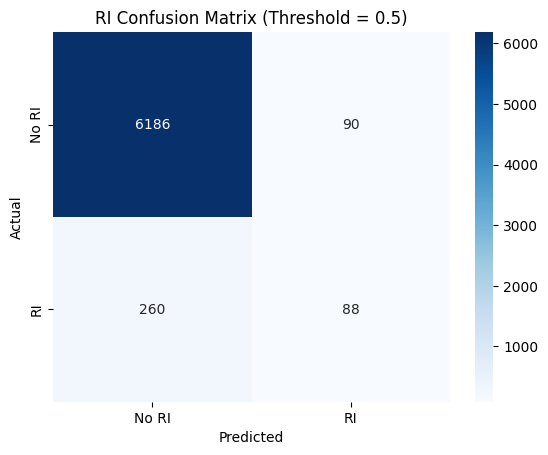


--- Visualizing Forecast for a Single Storm ---
Plotting forecast for storm: 1996353N05151 (FERN)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


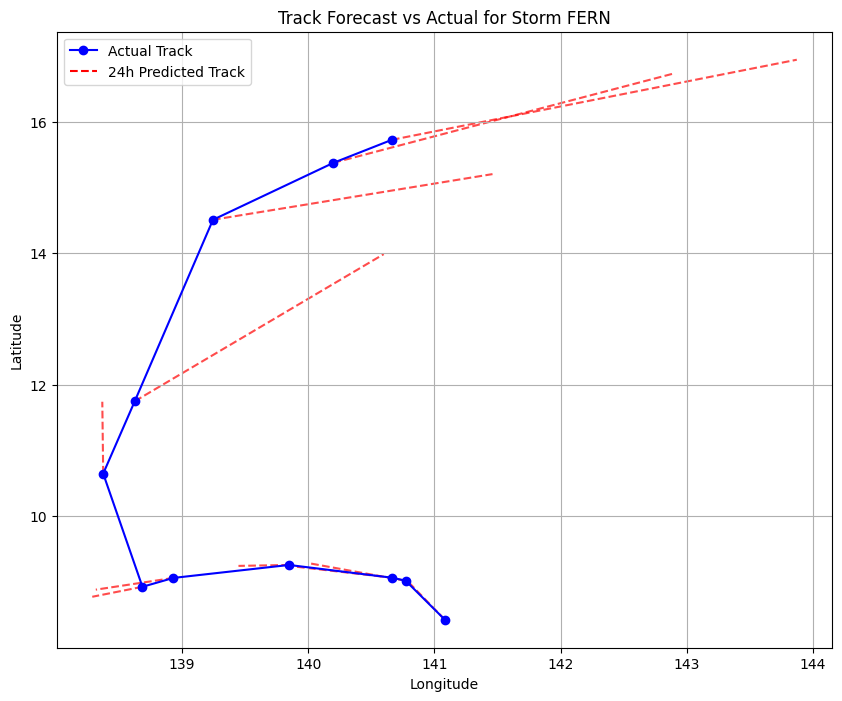

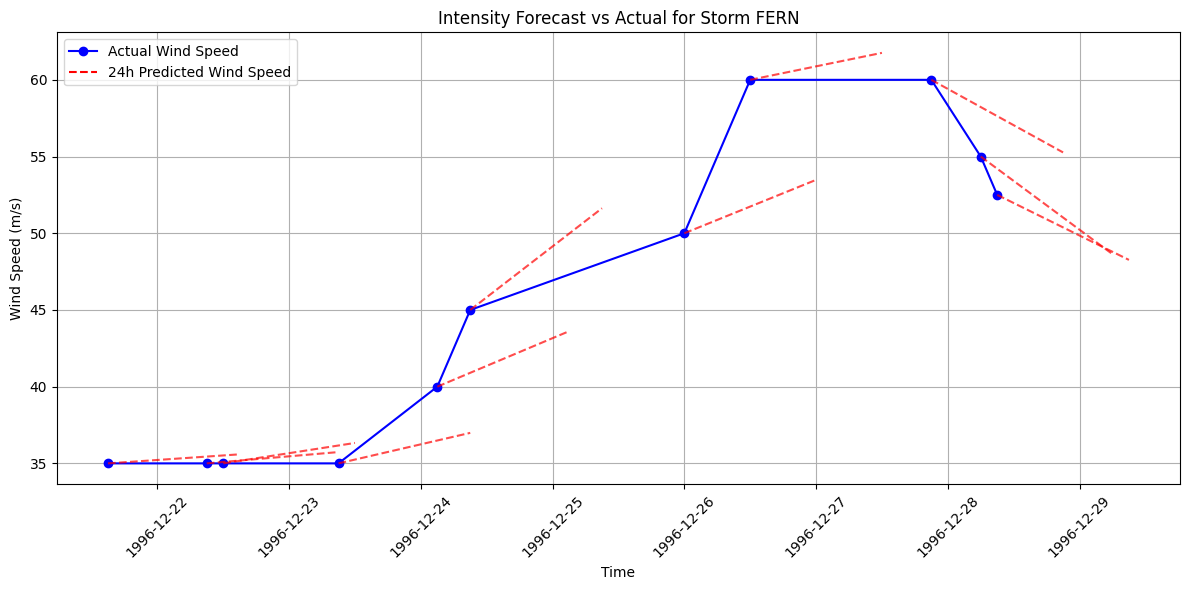

In [ ]:
# ==============================================================================
# Phase 5: Evaluation, Visualization, and Interpretation
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting Phase 5: Evaluation and Visualization...")

# --- 1. LOAD THE TRAINED MODEL ---
try:
    model = keras.models.load_model("typhoon_forecast_model.h5")
    print("Trained model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")

# --- 2. MAKE PREDICTIONS ON THE VALIDATION SET ---
# The validation data is already scaled and reshaped from Phase 4
predictions = model.predict([X_val_static_scaled, X_val_temporal_reshaped])

# The output is a list of 3 arrays, one for each head. Let's unpack them.
track_preds = predictions[0]
intensity_preds = predictions[1]
ri_preds = predictions[2].flatten() # Flatten to a 1D array

# --- 3. EVALUATE PERFORMANCE METRICS ---

# Helper function to calculate distance from lat/lon error (approximate)
def lat_lon_mae_to_km(lat_mae, lon_mae, avg_lat):
    lat_km = lat_mae * 111
    lon_km = lon_mae * 111 * np.cos(np.radians(avg_lat))
    return lat_km, lon_km

print("\n--- Model Performance Evaluation ---")

# a) Track Error
print("\n1. Track Forecast Error (Mean Absolute Error):")
avg_lat_val = y_val['LAT_fwd6'].mean() # Use an average latitude for km conversion
for i, h in enumerate(lead_times):
    lat_true = y_val[f'LAT_fwd{h}']
    lon_true = y_val[f'LON_fwd{h}']
    lat_pred = track_preds[:, i*2]
    lon_pred = track_preds[:, i*2+1]

    lat_mae = mean_absolute_error(lat_true, lat_pred)
    lon_mae = mean_absolute_error(lon_true, lon_pred)
    lat_km, lon_km = lat_lon_mae_to_km(lat_mae, lon_mae, avg_lat_val)

    print(f"  - {h}-hour forecast: Lat MAE = {lat_mae:.2f}°, Lon MAE = {lon_mae:.2f}° (~{lat_km:.1f} km, {lon_km:.1f} km)")

# b) Intensity Error
print("\n2. Intensity Forecast Error (Wind Speed MAE):")
for i, h in enumerate(lead_times):
    wind_true = y_val[f'WMO_WIND_fwd{h}']
    wind_pred = intensity_preds[:, i]
    wind_mae = mean_absolute_error(wind_true, wind_pred)
    print(f"  - {h}-hour forecast: Wind MAE = {wind_mae:.2f} m/s")

# c) Rapid Intensification (RI) Performance
print("\n3. Rapid Intensification Forecast Performance (for next 12h):")
ri_true = y_val['RI_12h_label']
auc_score = roc_auc_score(ri_true, ri_preds)
print(f"  - ROC AUC Score: {auc_score:.3f}")

# Create a confusion matrix
# We need to convert probabilities to binary predictions using a 0.5 threshold
ri_preds_binary = (ri_preds > 0.5).astype(int)
cm = confusion_matrix(ri_true, ri_preds_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No RI', 'RI'], yticklabels=['No RI', 'RI'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RI Confusion Matrix (Threshold = 0.5)")
plt.show()

# --- 4. VISUALIZE A FORECAST FOR A SINGLE STORM ---
print("\n--- Visualizing Forecast for a Single Storm ---")

# Select the first storm SID from the validation set
storm_to_plot_sid = val_df['SID'].iloc[0]
storm_df = val_df[val_df['SID'] == storm_to_plot_sid].sort_values(by='ISO_TIME')
print(f"Plotting forecast for storm: {storm_to_plot_sid} ({storm_df['NAME'].iloc[0]})")

# Prepare the data for this specific storm
storm_static_scaled = static_scaler.transform(storm_df[static_features])
storm_temporal_scaled = temporal_scaler.transform(storm_df[temporal_features])
storm_temporal_reshaped = storm_temporal_scaled.reshape(len(storm_temporal_scaled), 4, 6)

# Make predictions for just this storm
storm_preds = model.predict([storm_static_scaled, storm_temporal_reshaped])
storm_track_preds = storm_preds[0]
storm_intensity_preds = storm_preds[1]

# a) Plot Track Forecast
plt.figure(figsize=(10, 8))
# Plot the actual track
plt.plot(storm_df['LON'], storm_df['LAT'], 'o-', label='Actual Track', color='blue', zorder=2)

# Plot the model's 24-hour forecast from each point
for i in range(len(storm_df)):
    plt.plot(
        [storm_df['LON'].iloc[i], storm_track_preds[i, 2*2+1]], # Current Lon to 24h Lon
        [storm_df['LAT'].iloc[i], storm_track_preds[i, 2*2]],   # Current Lat to 24h Lat
        '--', color='red', alpha=0.7, zorder=1
    )
plt.plot([], [], '--', color='red', label='24h Predicted Track') # Dummy plot for legend
plt.title(f"Track Forecast vs Actual for Storm {storm_df['NAME'].iloc[0]}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

# b) Plot Intensity Forecast
plt.figure(figsize=(12, 6))
# Plot the actual intensity
plt.plot(storm_df['ISO_TIME'], storm_df['WMO_WIND'], 'o-', label='Actual Wind Speed', color='blue')

# Plot the model's 24-hour intensity forecast from each point
for i in range(len(storm_df)):
    forecast_time = storm_df['ISO_TIME'].iloc[i] + pd.Timedelta(hours=24)
    plt.plot(
        [storm_df['ISO_TIME'].iloc[i], forecast_time],
        [storm_df['WMO_WIND'].iloc[i], storm_intensity_preds[i, 2]], # Index 2 is the 24h forecast
        '--', color='red', alpha=0.7
    )
plt.plot([], [], '--', color='red', label='24h Predicted Wind Speed') # Dummy plot for legend
plt.title(f"Intensity Forecast vs Actual for Storm {storm_df['NAME'].iloc[0]}")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()